Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Logistic Regression Accuracy: 0.7886
Random Forest Accuracy: 0.7886

Best Model: Logistic Regression (Accuracy: 0.7886)

Classification Report (Random Forest):
              precision    recall  f1-score   support

    Rejected       0.80      0.42      0.55        38
    Approved       0.79      0.95      0.86        85

    accuracy                           0.79       123
   macro avg       0.79      0.69      0.71       123
weighted avg       0.79      0.79      0.77       123



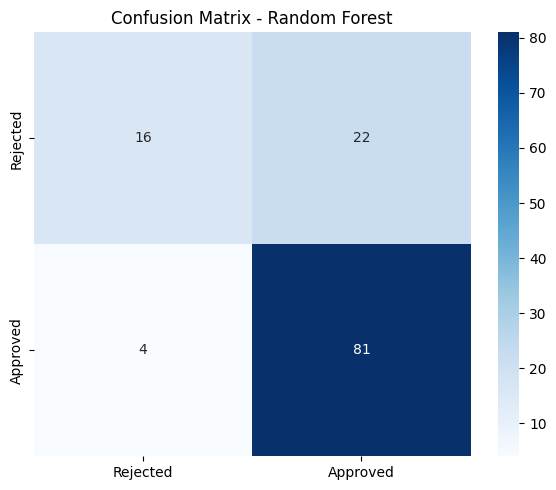

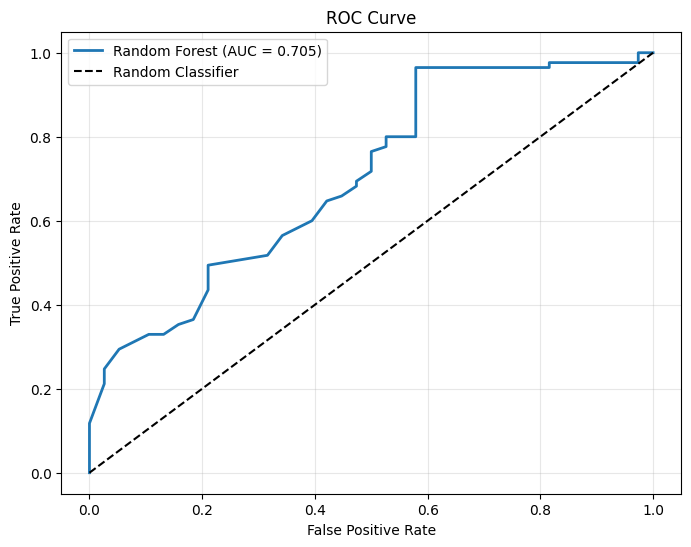


Top 10 Important Features:
Credit_History: 0.2698
Loan_ID: 0.1541
ApplicantIncome: 0.1502
LoanAmount: 0.1350
CoapplicantIncome: 0.0956
Property_Area: 0.0488
Loan_Amount_Term: 0.0389
Dependents: 0.0362
Married: 0.0243
Education: 0.0178


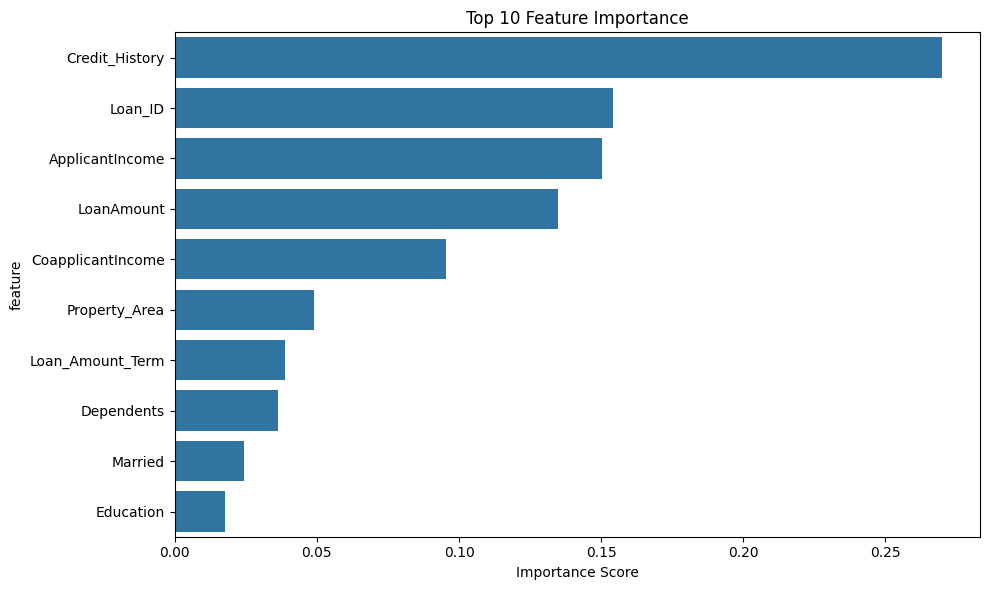


Model saved as 'loan_model.pkl'

Prediction Result:
LOAN REJECTED
Confidence: 4.28%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# TASK 3: LOAN APPROVAL PREDICTION
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load dataset
data_path = '/content/loan_prediction.csv'

try:
    data = pd.read_csv(data_path)
except:
    from google.colab import files
    uploaded = files.upload()
    data_path = list(uploaded.keys())[0]
    data = pd.read_csv(data_path)

# Find target column
target_name = None
for col in data.columns:
    if 'status' in col.lower() or 'approved' in col.lower() or 'loan_status' in col.lower():
        target_name = col
        break
if target_name is None:
    target_name = data.columns[-1]

# Convert target column to 0 and 1
if data[target_name].dtype == 'object' or data[target_name].dtype.name == 'category':
    unique_values = data[target_name].unique()
    if 'Y' in unique_values and 'N' in unique_values:
        data[target_name] = data[target_name].map({'Y': 1, 'N': 0})
    elif 'Approved' in unique_values and 'Rejected' in unique_values:
        data[target_name] = data[target_name].map({'Approved': 1, 'Rejected': 0})
    else:
        label_encoder_target = LabelEncoder()
        data[target_name] = label_encoder_target.fit_transform(data[target_name])
data[target_name] = data[target_name].astype(int)

# Handle missing values
for column in data.columns:
    if data[column].isnull().sum() > 0:
        if data[column].dtype in ['int64', 'float64']:
            data[column].fillna(data[column].median(), inplace=True)
        else:
            data[column].fillna(data[column].mode()[0], inplace=True)

# Encode categorical variables
categorical_encoders = {}
for column in data.select_dtypes(include=['object']).columns:
    if column != target_name:
        encoder = LabelEncoder()
        data[column] = encoder.fit_transform(data[column])
        categorical_encoders[column] = encoder

# Split features and target
features = data.drop(target_name, axis=1)
target = data[target_name]

# Train test split
train_features, test_features, train_target, test_target = train_test_split(features, target, test_size=0.2, random_state=7, stratify=target)

# Scale features
feature_scaler = StandardScaler()
train_features_scaled = feature_scaler.fit_transform(train_features)
test_features_scaled = feature_scaler.transform(test_features)

# Train Logistic Regression
logistic_model = LogisticRegression(random_state=7, max_iter=1000)
logistic_model.fit(train_features_scaled, train_target)

# Train Random Forest
forest_model = RandomForestClassifier(n_estimators=100, random_state=7)
forest_model.fit(train_features_scaled, train_target)

# Make predictions
logistic_predictions = logistic_model.predict(test_features_scaled)
forest_predictions = forest_model.predict(test_features_scaled)

# Calculate accuracy
logistic_accuracy = accuracy_score(test_target, logistic_predictions)
forest_accuracy = accuracy_score(test_target, forest_predictions)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")
print(f"Random Forest Accuracy: {forest_accuracy:.4f}")

# Select best model
if forest_accuracy > logistic_accuracy:
    final_model = forest_model
    print(f"\nBest Model: Random Forest (Accuracy: {forest_accuracy:.4f})")
else:
    final_model = logistic_model
    print(f"\nBest Model: Logistic Regression (Accuracy: {logistic_accuracy:.4f})")

# Classification Report
print("\nClassification Report (Random Forest):")
print(classification_report(test_target, forest_predictions, target_names=['Rejected', 'Approved']))

# Confusion Matrix
conf_matrix = confusion_matrix(test_target, forest_predictions)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# ROC Curve
forest_probabilities = forest_model.predict_proba(test_features_scaled)[:, 1]
roc_auc = roc_auc_score(test_target, forest_probabilities)
false_pos, true_pos, _ = roc_curve(test_target, forest_probabilities)

plt.figure(figsize=(8,6))
plt.plot(false_pos, true_pos, label=f'Random Forest (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve.png')
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    'feature': features.columns,
    'importance': forest_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Important Features:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# Save model
joblib.dump(final_model, 'loan_model.pkl')
joblib.dump(feature_scaler, 'scaler.pkl')
joblib.dump(categorical_encoders, 'encoders.pkl')
joblib.dump(features.columns.tolist(), 'columns_list.pkl')

print("\nModel saved as 'loan_model.pkl'")

# Prediction function
def predict_approval(applicant_info):
    input_data = pd.DataFrame([applicant_info])

    for col, enc in categorical_encoders.items():
        if col in input_data.columns:
            try:
                input_data[col] = enc.transform([input_data[col].iloc[0]])[0]
            except:
                input_data[col] = 0

    for col in features.columns:
        if col not in input_data.columns:
            input_data[col] = 0

    input_data = input_data[features.columns]
    input_scaled = feature_scaler.transform(input_data)

    prediction = final_model.predict(input_scaled)[0]
    confidence = final_model.predict_proba(input_scaled)[0][1]

    return prediction, confidence

# Test prediction
sample_applicant = {}
for col in features.columns:
    if 'age' in col:
        sample_applicant[col] = 35
    elif 'income' in col:
        sample_applicant[col] = 75000
    elif 'emp' in col:
        sample_applicant[col] = 5
    elif 'amnt' in col:
        sample_applicant[col] = 25000
    elif 'rate' in col:
        sample_applicant[col] = 11.5
    elif 'percent' in col:
        sample_applicant[col] = 0.33
    elif 'cred_hist' in col:
        sample_applicant[col] = 8
    else:
        sample_applicant[col] = 0

result, confidence_score = predict_approval(sample_applicant)

print(f"\nPrediction Result:")
if result == 1:
    print(f"LOAN APPROVED")
else:
    print(f"LOAN REJECTED")
print(f"Confidence: {confidence_score*100:.2f}%")

# Download files (Colab)
try:
    from google.colab import files
    files.download('loan_model.pkl')
    files.download('confusion_matrix.png')
    files.download('roc_curve.png')
    files.download('feature_importance.png')
except:
    pass

